# 07 — Validação Adversarial: onde treino e Kaggle diferem
## PRT Seguros

**Ideia:** se treino e Kaggle viessem exatamente da mesma distribuição, um classificador não
conseguiria diferenciar de qual base uma linha veio (AUC ≈ 0.50). Se conseguir diferenciar bem
(AUC alto), isso prova e **quantifica** o *distribution shift* que já suspeitávamos (o bug da
`regiao_Centro-Oeste` foi encontrado "no olho" comparando médias — aqui fazemos isso de forma
sistemática para as ~70 features de uma vez).

**Como funciona:**
1. Empilha treino + validação (rótulo `origem=0`) e Kaggle (rótulo `origem=1`)
2. Treina um classificador para prever `origem` a partir das features (nunca do `churned`, que nem existe no Kaggle)
3. Mede o AUC desse classificador em cross-validation — quanto mais longe de 0.50, maior o shift
4. Olha a *feature importance* desse classificador: as features no topo são as que mais "denunciam" a origem — ou seja, as mais candidatas a ter bug de encoding/tratamento diferente entre as duas bases


## 1. Imports e carregar dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

PRT_NAVY  = "#19284F"
PRT_GREEN = "#39694B"
PRT_GRAY  = "#737C8A"
RANDOM_STATE = 42

train = pd.read_csv("dados_processados/train_model_ready.csv")
val = pd.read_csv("dados_processados/val_model_ready.csv")
kaggle = pd.read_csv("dados_processados/kaggle_model_ready.csv")

ID_COL, TARGET_COL = "cod_individuo", "churned"
feature_cols = [c for c in kaggle.columns if c != ID_COL]

print(f"Treino+Val: {len(train) + len(val):,} linhas | Kaggle: {len(kaggle):,} linhas")
print(f"Features usadas: {len(feature_cols)}")


Treino+Val: 100,000 linhas | Kaggle: 100,000 linhas
Features usadas: 72


## 2. Montar o dataset adversarial

`origem = 0` → veio do treino/validação (`Base_Unificada_Outer.csv`)
`origem = 1` → veio do Kaggle (`Base_Unificada_Kaggle_Outer.csv`)

O `cluster` também entra como feature — ele foi gerado por um K-Means ajustado só no treino,
então se o Kaggle tiver uma distribuição de clusters muito diferente, isso também é sinal de shift.

In [2]:
treino_completo = pd.concat([train[feature_cols], val[feature_cols]], ignore_index=True)

X_adv = pd.concat([treino_completo, kaggle[feature_cols]], ignore_index=True)
y_adv = np.concatenate([
    np.zeros(len(treino_completo), dtype=int),
    np.ones(len(kaggle), dtype=int),
])

print(f"X_adv: {X_adv.shape} | proporção Kaggle: {y_adv.mean():.1%}")


X_adv: (200000, 72) | proporção Kaggle: 50.0%


## 3. Treinar o classificador adversarial (5-fold CV)

Usamos LightGBM (rápido, lida bem com esse volume de linhas) e `cross_val_predict` para gerar
probabilidades *out-of-fold* — cada previsão vem de um modelo que nunca viu aquela linha,
então o AUC final é uma estimativa honesta de quão separáveis as duas bases são.

In [3]:
adv_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    num_leaves=31,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
proba_oof = cross_val_predict(adv_model, X_adv, y_adv, cv=cv, method="predict_proba", n_jobs=1)[:, 1]

auc_adversarial = roc_auc_score(y_adv, proba_oof)
print(f"AUC adversarial (out-of-fold): {auc_adversarial:.4f}")
print()
if auc_adversarial < 0.55:
    print("Quase indistinguível — treino e Kaggle têm distribuições muito parecidas.")
elif auc_adversarial < 0.65:
    print("Shift leve — algumas features divergem, mas nada crítico.")
elif auc_adversarial < 0.80:
    print("Shift moderado — vale a pena investigar e possivelmente remover as features mais culpadas.")
else:
    print("Shift forte — treino e Kaggle são bem diferentes nessas features; isso ajuda a "
          "explicar a queda de AUC-ROC de validação (~0.82) para o público do Kaggle (~0.74).")


AUC adversarial (out-of-fold): 0.7177

Shift moderado — vale a pena investigar e possivelmente remover as features mais culpadas.


## 4. Quais features mais denunciam a origem (feature importance)

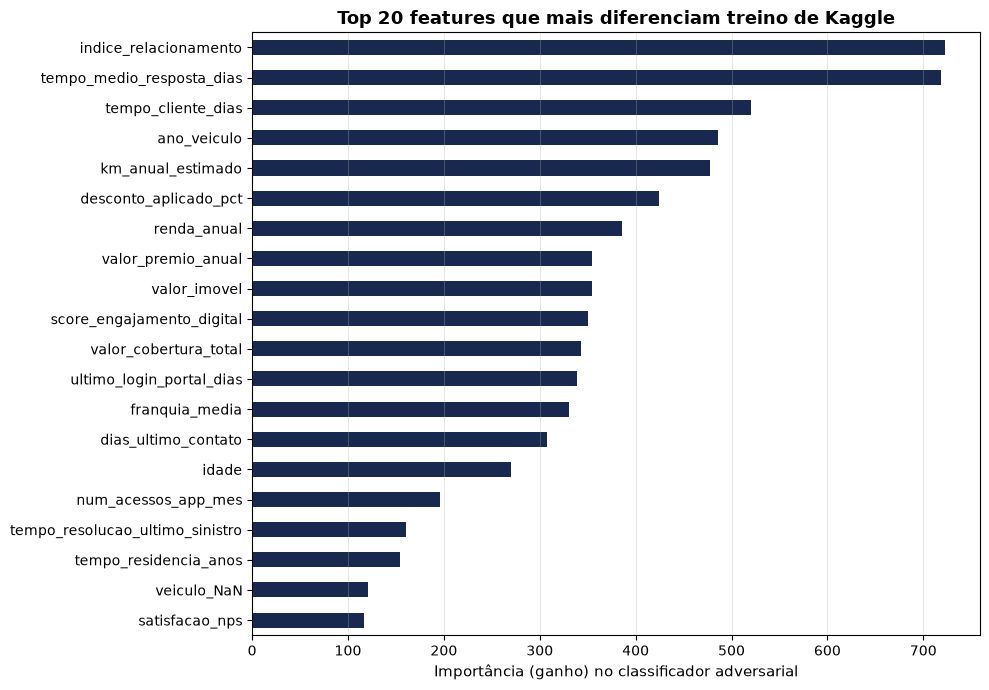

indice_relacionamento              723
tempo_medio_resposta_dias          718
tempo_cliente_dias                 520
ano_veiculo                        486
km_anual_estimado                  478
desconto_aplicado_pct              424
renda_anual                        386
valor_premio_anual                 355
valor_imovel                       354
score_engajamento_digital          350
valor_cobertura_total              343
ultimo_login_portal_dias           339
franquia_media                     331
dias_ultimo_contato                308
idade                              270
num_acessos_app_mes                196
tempo_resolucao_ultimo_sinistro    160
tempo_residencia_anos              154
veiculo_NaN                        121
satisfacao_nps                     117
dtype: int32


In [4]:
adv_model_full = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    num_leaves=31,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
adv_model_full.fit(X_adv, y_adv)

importancias = pd.Series(
    adv_model_full.feature_importances_, index=feature_cols
).sort_values(ascending=False)

top20 = importancias.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20.sort_values().plot(kind="barh", ax=ax, color=PRT_NAVY)
ax.set_title("Top 20 features que mais diferenciam treino de Kaggle", fontsize=13, fontweight="bold")
ax.set_xlabel("Importância (ganho) no classificador adversarial", fontsize=11)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print(top20)


## 5. Detalhar as features mais suspeitas: treino vs. Kaggle

Para cada uma das top 10 features do classificador adversarial, comparamos média/proporção entre
treino e Kaggle — o mesmo tipo de comparação que encontrou o bug da `regiao_Centro-Oeste`, mas
agora direcionada pelas features que o modelo apontou como mais discriminativas.

In [5]:
top10 = importancias.head(10).index.tolist()

comparacao = pd.DataFrame({
    "media_treino": treino_completo[top10].mean(),
    "media_kaggle": kaggle[top10].mean(),
})
comparacao["diff_absoluta"] = (comparacao["media_kaggle"] - comparacao["media_treino"]).abs()
comparacao["diff_relativa_pct"] = (
    comparacao["diff_absoluta"] / comparacao["media_treino"].abs().replace(0, np.nan) * 100
).round(1)
comparacao = comparacao.sort_values("diff_absoluta", ascending=False)
comparacao


,media_treino,media_kaggle,diff_absoluta,diff_relativa_pct
valor_imovel,298983.710000,298149.960000,833.750000,0.3
renda_anual,79466.249000,79698.978500,232.729500,0.3
km_anual_estimado,18047.901000,18004.348000,43.553000,0.2
tempo_cliente_dias,2356.811690,2352.283830,4.527860,0.2
valor_premio_anual,1296.675255,1298.696823,2.021568,0.2
indice_relacionamento,54.126109,54.248466,0.122357,0.2
ano_veiculo,2014.563700,2014.480670,0.083030,0.0
score_engajamento_digital,51.170360,51.211010,0.040650,0.1
tempo_medio_resposta_dias,2.727623,2.755476,0.027853,1.0
desconto_aplicado_pct,0.096087,0.096091,0.000004,0.0


## 6. Conclusão

- Se o AUC adversarial ficar bem acima de 0.5, ele **confirma numericamente** o distribution shift
  que já víamos "no olho".
- A lista de features do passo 4/5 é o mapa de onde investigar — para cada uma, vale voltar nos
  notebooks de tratamento (`Analise_descritiva/`, `bases/bases_kaggle/unificacao_kaggle_outer.ipynb`)
  e comparar como aquela coluna específica foi limpa/derivada em cada pipeline.
- Uma estratégia direta a partir daqui: **remover as features mais "delatoras"** do treino dos
  modelos (ou re-tratá-las para ficarem consistentes, como fizemos com `regiao`) e comparar o AUC
  de validação antes/depois — se a validação cair mas o score do Kaggle subir, é sinal de que
  aquela feature estava ensinando o modelo a decorar um padrão que só existe no treino.
